In [42]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    KFold,
    train_test_split,
    cross_val_score,
    GridSearchCV,
)

In [43]:
def apply_mpl_config():
    print("Apply custom plotting configs...")
    mpl_config = {
        "figure.figsize": (12, 6),
        "savefig.dpi": 300,
        "figure.dpi": 150,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
        "text.usetex": True,
        "font.size": 11,
        "axes.labelsize": 10,
        "axes.titlesize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "axes.linewidth": 0.8,
        "savefig.bbox": "tight",
    }

    mpl.rcParams.update(mpl_config)
    print("Done!")

In [44]:
apply_mpl_config()

Apply custom plotting configs...
Done!


In [45]:
train = pd.read_csv("./train.csv")
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Cement_component1__kgInAM_3Mixture_            800 non-null    float64
 1   BlastFurnaceSlag_component2__kgInAM_3Mixture_  800 non-null    float64
 2   FlyAsh_component3__kgInAM_3Mixture_            800 non-null    float64
 3   Water_component4__kgInAM_3Mixture_             800 non-null    float64
 4   Superplasticizer_component5__kgInAM_3Mixture_  800 non-null    float64
 5   CoarseAggregate_component6__kgInAM_3Mixture_   800 non-null    float64
 6   FineAggregate_component7__kgInAM_3Mixture_     800 non-null    float64
 7   Age_day_                                       800 non-null    int64  
 8   ConcreteCompressiveStrength_MPa_Megapascals_   800 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 56.4 KB


In [46]:
test = pd.read_csv("./test.csv")
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Cement_component1__kgInAM_3Mixture_            100 non-null    float64
 1   BlastFurnaceSlag_component2__kgInAM_3Mixture_  100 non-null    float64
 2   FlyAsh_component3__kgInAM_3Mixture_            100 non-null    float64
 3   Water_component4__kgInAM_3Mixture_             100 non-null    float64
 4   Superplasticizer_component5__kgInAM_3Mixture_  100 non-null    float64
 5   CoarseAggregate_component6__kgInAM_3Mixture_   100 non-null    float64
 6   FineAggregate_component7__kgInAM_3Mixture_     100 non-null    float64
 7   Age_day_                                       100 non-null    int64  
 8   ConcreteCompressiveStrength_MPa_Megapascals_   100 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 7.2 KB


In [47]:
train.head()

,Cement_component1__kgInAM_3Mixture_,BlastFurnaceSlag_component2__kgInAM_3Mixture_,FlyAsh_component3__kgInAM_3Mixture_,Water_component4__kgInAM_3Mixture_,Superplasticizer_component5__kgInAM_3Mixture_,CoarseAggregate_component6__kgInAM_3Mixture_,FineAggregate_component7__kgInAM_3Mixture_,Age_day_,ConcreteCompressiveStrength_MPa_Megapascals_
0,153.0,145.0,0.0,178.0,8.0,1000.0,822.0,28,19.008853
1,525.0,0.0,0.0,189.0,0.0,1125.0,613.0,14,48.401215
2,379.5,151.2,0.0,153.9,15.9,1134.3,605.0,3,28.599464
3,540.0,0.0,0.0,173.0,0.0,1125.0,613.0,90,69.657760
4,143.8,136.3,106.2,178.1,7.5,941.5,774.3,28,26.147688


In [48]:
test.columns

Index(['Cement_component1__kgInAM_3Mixture_',
       'BlastFurnaceSlag_component2__kgInAM_3Mixture_',
       'FlyAsh_component3__kgInAM_3Mixture_',
       'Water_component4__kgInAM_3Mixture_',
       'Superplasticizer_component5__kgInAM_3Mixture_',
       'CoarseAggregate_component6__kgInAM_3Mixture_',
       'FineAggregate_component7__kgInAM_3Mixture_', 'Age_day_',
       'ConcreteCompressiveStrength_MPa_Megapascals_'],
      dtype='str')

In [49]:
original_cols = [
    "Cement_component1__kgInAM_3Mixture_",
    "BlastFurnaceSlag_component2__kgInAM_3Mixture_",
    "FlyAsh_component3__kgInAM_3Mixture_",
    "Water_component4__kgInAM_3Mixture_",
    "Superplasticizer_component5__kgInAM_3Mixture_",
    "CoarseAggregate_component6__kgInAM_3Mixture_",
    "FineAggregate_component7__kgInAM_3Mixture_",
    "Age_day_",
    "ConcreteCompressiveStrength_MPa_Megapascals_",
]

In [50]:
simple_cols = [
    "Cement",
    "BlastFurnaceSlag",
    "FlyAsh",
    "Water",
    "Superplasticizer",
    "CoarseAggregate",
    "FineAggregate",
    "Age_day",
    "ConcCompStrength_MPa",
]

In [51]:
# Rename columns in train and test
train.columns = simple_cols
test.columns = simple_cols

In [52]:
train.head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age_day,ConcCompStrength_MPa
0,153.0,145.0,0.0,178.0,8.0,1000.0,822.0,28,19.008853
1,525.0,0.0,0.0,189.0,0.0,1125.0,613.0,14,48.401215
2,379.5,151.2,0.0,153.9,15.9,1134.3,605.0,3,28.599464
3,540.0,0.0,0.0,173.0,0.0,1125.0,613.0,90,69.657760
4,143.8,136.3,106.2,178.1,7.5,941.5,774.3,28,26.147688


In [53]:
X_train = train.drop("ConcCompStrength_MPa", axis=1)
y_train = train["ConcCompStrength_MPa"]

X_test_holdout = test.drop("ConcCompStrength_MPa", axis=1)
y_test_holdout = test["ConcCompStrength_MPa"]

In [54]:
def calc_rse(y_test, y_pred, p):
    """
    Calculate RSE - Residual Standard Error

    Args:
        y_test: test set
        y_pred: predicted set
        p: number of features

    Returns RSE
    """
    n = len(y_test)
    df = n - p - 1

    assert n == len(y_pred), "Prediction and target length mismatch"
    assert n > p + 1, f"Insufficient samples: need n > {p+1}, got {n}"

    residuals = y_test - y_pred
    rss = np.sum(residuals**2)

    return np.sqrt(rss / df)


def calc_r2(y_test, y_pred):
    """
    Calculate R^2 - Coefficient of determination

    Args:
        Args:
        y_test: test set
        y_pred: predicted set

    Returns R^2
    """
    assert len(y_test) == len(y_pred), "Prediction and target length mismatch"

    ss_res = np.sum((y_test - y_pred) ** 2)  # sum of squares residuals
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)  # sum of squares total

    return 1 - (ss_res / ss_tot)

In [55]:
p = X_train.shape[1]  # n_features
print(f"Number of features: {p}")

Number of features: 8


## Question 1


In [56]:
# Split: train 60, val 20, test 20

# 80% temp, 20% test
X_temp, X_val_test, y_temp, y_val_test = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, shuffle=True
)

# 60% train, 20% val (from the 80% temp)
X_val_train, X_val_val, y_val_train, y_val_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True  # 0.25 * 0.8 = 0.2
)

print(
    f"Train size: {len(X_val_train)} ({len(X_val_train)/len(X_train)*100:.1f}%)")
print(
    f"Validation size: {len(X_val_val)} ({len(X_val_val)/len(X_train)*100:.1f}%)")
print(
    f"Test size: {len(X_val_test)} ({len(X_val_test)/len(X_train)*100:.1f}%)")
print(f"Total: {len(X_train):4d} samples")

Train size: 480 (60.0%)
Validation size: 160 (20.0%)
Test size: 160 (20.0%)
Total:  800 samples


In [57]:
# Combine train + val
X_train_full = pd.concat([X_val_train, X_val_val], axis=0)
y_train_full = pd.concat([y_val_train, y_val_val], axis=0)

In [58]:
# define scaler
scaler = StandardScaler()

# Define linear regression model (ols)
reg = LinearRegression()

# Define Pipeline
pipe_lr = Pipeline([("scaler", scaler), ("reg", reg)])

# Train on train + val (full)
pipe_lr.fit(X_train_full, y_train_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


### Validation Approach Results

In [59]:
# Predict on held-out test set (20%)
y_pred_val = pipe_lr.predict(X_val_test.values)

# Calculate metrics
p = X_train.shape[1]  # number of features
rse_val = calc_rse(y_val_test, y_pred_val, p)
r2_val = calc_r2(y_val_test, y_pred_val)
rmse_val = np.sqrt(np.mean((y_val_test - y_pred_val)**2))

print(f"\nValidation Approach Results (on 20% hold-out test):")
print(f"  RMSE: {rmse_val:.4f}")
print(f"  RSE:  {rse_val:.4f}")
print(f"  R²:   {r2_val:.4f}")


Validation Approach Results (on 20% hold-out test):
  RMSE: 11.3177
  RSE:  11.6501
  R²:   0.5445


/Users/isaacadoboe/Developer/mun-sc-journey/Winter2026/COMP6915/assignments/assignment_2/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Cross-validation


In [60]:
n_folds = [5, 10]  # testing diff folds
cv_results = {}


for n_folds in n_folds:
    print(f"\n{'='*60}")
    print(f"Cross-Validation with k={n_folds} folds")
    print(f"{'='*60}")

    # Create fresh pipeline for CV
    pipe_cv = Pipeline([
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ])

    # Set up k-fold CV
    cv = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    # Perform cross-validation on FULL train.csv
    neg_mse_scores = cross_val_score(
        pipe_cv,
        X_train,  # ← Use FULL training data
        y_train,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

    # Convert to RMSE
    mse_scores = -neg_mse_scores
    rmse_scores = np.sqrt(mse_scores)

    # Calculate statistics
    rmse_mean = np.mean(rmse_scores)
    rmse_std = np.std(rmse_scores)
    rmse_se = rmse_std / np.sqrt(n_folds)  # Standard error of the mean

    # Store results
    cv_results[n_folds] = {
        'rmse_mean': rmse_mean,
        'rmse_std': rmse_std,
        'rmse_se': rmse_se,
        'rmse_scores': rmse_scores,
        'train_size_per_fold': len(X_train) * (n_folds - 1) / n_folds
    }

    print(
        f"  Training samples per fold: {cv_results[n_folds]['train_size_per_fold']:.0f}")
    print(f"  Test samples per fold:     {len(X_train) / n_folds:.0f}")
    print(f"  RMSE: {rmse_mean:.4f} ± {rmse_std:.4f} (std)")
    print(f"        {rmse_mean:.4f} ± {rmse_se:.4f} (SE)")
    print(
        f"  RMSE range: [{np.min(rmse_scores):.4f}, {np.max(rmse_scores):.4f}]")
    print(
        f"  95% CI (approx): [{rmse_mean - 1.96*rmse_se:.4f}, {rmse_mean + 1.96*rmse_se:.4f}]")


Cross-Validation with k=5 folds
  Training samples per fold: 640
  Test samples per fold:     160
  RMSE: 10.3983 ± 0.5324 (std)
        10.3983 ± 0.2381 (SE)
  RMSE range: [9.6806, 11.3177]
  95% CI (approx): [9.9317, 10.8650]

Cross-Validation with k=10 folds
  Training samples per fold: 720
  Test samples per fold:     80
  RMSE: 10.3324 ± 0.6734 (std)
        10.3324 ± 0.2130 (SE)
  RMSE range: [9.4170, 11.6118]
  95% CI (approx): [9.9150, 10.7498]


In [61]:
print("\n" + "="*70)
print("COMPARISON: Validation vs Cross-Validation Approaches")
print("="*70)

print(f"\n1. VALIDATION APPROACH (60% train + 20% val → test on 20%):")
print(f"   RMSE = {rmse_val:.4f}")
print(f"   RSE  = {rse_val:.4f}")
print(f"   R²   = {r2_val:.4f}")
print(f"   Test set size: {len(X_val_test)} samples")

print(f"\n2. CROSS-VALIDATION (5-fold on 100% of data):")
print(
    f"   RMSE = {cv_results[5]['rmse_mean']:.4f} ± {cv_results[5]['rmse_se']:.4f} (SE)")
print(
    f"   Training per fold: {cv_results[5]['train_size_per_fold']:.0f} samples (80%)")
print(f"   Test per fold: {len(X_train)/5:.0f} samples (20%)")

print(f"\n3. CROSS-VALIDATION (10-fold on 100% of data):")
print(
    f"   RMSE = {cv_results[10]['rmse_mean']:.4f} ± {cv_results[10]['rmse_se']:.4f} (SE)")
print(
    f"   Training per fold: {cv_results[10]['train_size_per_fold']:.0f} samples (90%)")
print(f"   Test per fold: {len(X_train)/10:.0f} samples (10%)")

performance_results = {
    "OLS_validation": {
        "RMSE": rmse_val,
        "RSE": rse_val,
        "R2": r2_val,
    },
    "OLS_CV5": {
        "RMSE": cv_results[5]['rmse_mean'],
        "RMSE_std": cv_results[5]['rmse_std'],
    },
    "OLS_CV10": {
        "RMSE": cv_results[10]['rmse_mean'],
        "RMSE_std": cv_results[10]['rmse_std']
    }
}


COMPARISON: Validation vs Cross-Validation Approaches

1. VALIDATION APPROACH (60% train + 20% val → test on 20%):
   RMSE = 11.3177
   RSE  = 11.6501
   R²   = 0.5445
   Test set size: 160 samples

2. CROSS-VALIDATION (5-fold on 100% of data):
   RMSE = 10.3983 ± 0.2381 (SE)
   Training per fold: 640 samples (80%)
   Test per fold: 160 samples (20%)

3. CROSS-VALIDATION (10-fold on 100% of data):
   RMSE = 10.3324 ± 0.2130 (SE)
   Training per fold: 720 samples (90%)
   Test per fold: 80 samples (10%)


In [62]:
performance_results = {}

In [63]:
# Train on full train.csv
pipe_ols_final = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])
pipe_ols_final.fit(X_train, y_train)

# Predict on test (train test subset)
y_pred_ols = pipe_ols_final.predict(X_test_holdout)

# Calc errors
rse_ols = calc_rse(y_test_holdout, y_pred_ols, p)
rmse_ols = np.sqrt(np.mean((y_test_holdout - y_pred_ols)**2))
r2_ols = calc_r2(y_test_holdout, y_pred_ols)

performance_results["OLS"] = {
    "RMSE": rmse_ols,
    "RSE": rse_ols,
    "R2": r2_ols,
    "note": "Trained on train.csv, tested on test.csv"
}

print(f"RSE:  {rse_ols:.4f}")
print(f"R^2:   {r2_ols:.4f}")

RSE:  10.0023
R^2:   0.5953


## Question 2


### Grid Search with Cross-Validation

In [64]:
# Define Ridge pipeline
pipe_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

# Define alpha grid (logarithmic spacing for better coverage)
alphas = np.logspace(-3, 3, 50)  # 0.001 to 1000
param_grid = {"ridge__alpha": alphas}

print(f"\nGrid Search Configuration:")
print(f"  Alpha range: [{alphas[0]:.4f}, {alphas[-1]:.2f}]")
print(f"  Number of alpha values: {len(alphas)}")
print(f"  Cross-validation: 10-fold")
print(f"  Training data: Full train.csv ({len(X_train)} samples)")

# Perform grid search with 10-fold CV
cv = KFold(n_splits=10, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    pipe_ridge,
    param_grid,
    cv=cv,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

print(f"\nRunning Grid Search...")
grid_search.fit(X_train, y_train)

# Extract results
best_alpha_ridge = grid_search.best_params_["ridge__alpha"]
best_cv_rmse = np.sqrt(-grid_search.best_score_)
cv_results_grid = grid_search.cv_results_

print(f"\n{'='*70}")
print(f"BEST HYPERPARAMETER FOUND:")
print(f"{'='*70}")
print(f"Best alpha: {best_alpha_ridge:.6f}")
print(f"Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}")


Grid Search Configuration:
  Alpha range: [0.0010, 1000.00]
  Number of alpha values: 50
  Cross-validation: 10-fold
  Training data: Full train.csv (800 samples)

Running Grid Search...
Fitting 10 folds for each of 50 candidates, totalling 500 fits

BEST HYPERPARAMETER FOUND:
Best alpha: 1.526418
Best CV RMSE: 10.3534


In [65]:
# Extract training and validation scores
alphas_tested = cv_results_grid['param_ridge__alpha'].data
mean_train_rmse = np.sqrt(-cv_results_grid['mean_train_score'])
mean_test_rmse = np.sqrt(-cv_results_grid['mean_test_score'])
std_test_rmse = np.sqrt(cv_results_grid['std_test_score'])

# Find min/max performance
idx_best = np.argmin(mean_test_rmse)
idx_worst = np.argmax(mean_test_rmse)

print(f"\nPerformance Range:")
print(
    f"  Best  (alpha={alphas_tested[idx_best]:.4f}): RMSE = {mean_test_rmse[idx_best]:.4f}")
print(
    f"  Worst (alpha={alphas_tested[idx_worst]:.4f}): RMSE = {mean_test_rmse[idx_worst]:.4f}")
print(
    f"  Performance degradation: {((mean_test_rmse[idx_worst]/mean_test_rmse[idx_best] - 1)*100):.2f}%")


Performance Range:
  Best  (alpha=1.5264): RMSE = 10.3534
  Worst (alpha=1000.0000): RMSE = 12.9789
  Performance degradation: 25.36%


<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/var/folders/tl/52w5zxkd1zl65mr95qllj_3h0000gn/T/ipykernel_21161/3898462725.py:12: SyntaxWarning: invalid escape sequence '\p'
  label='$\pm$ 1 std'


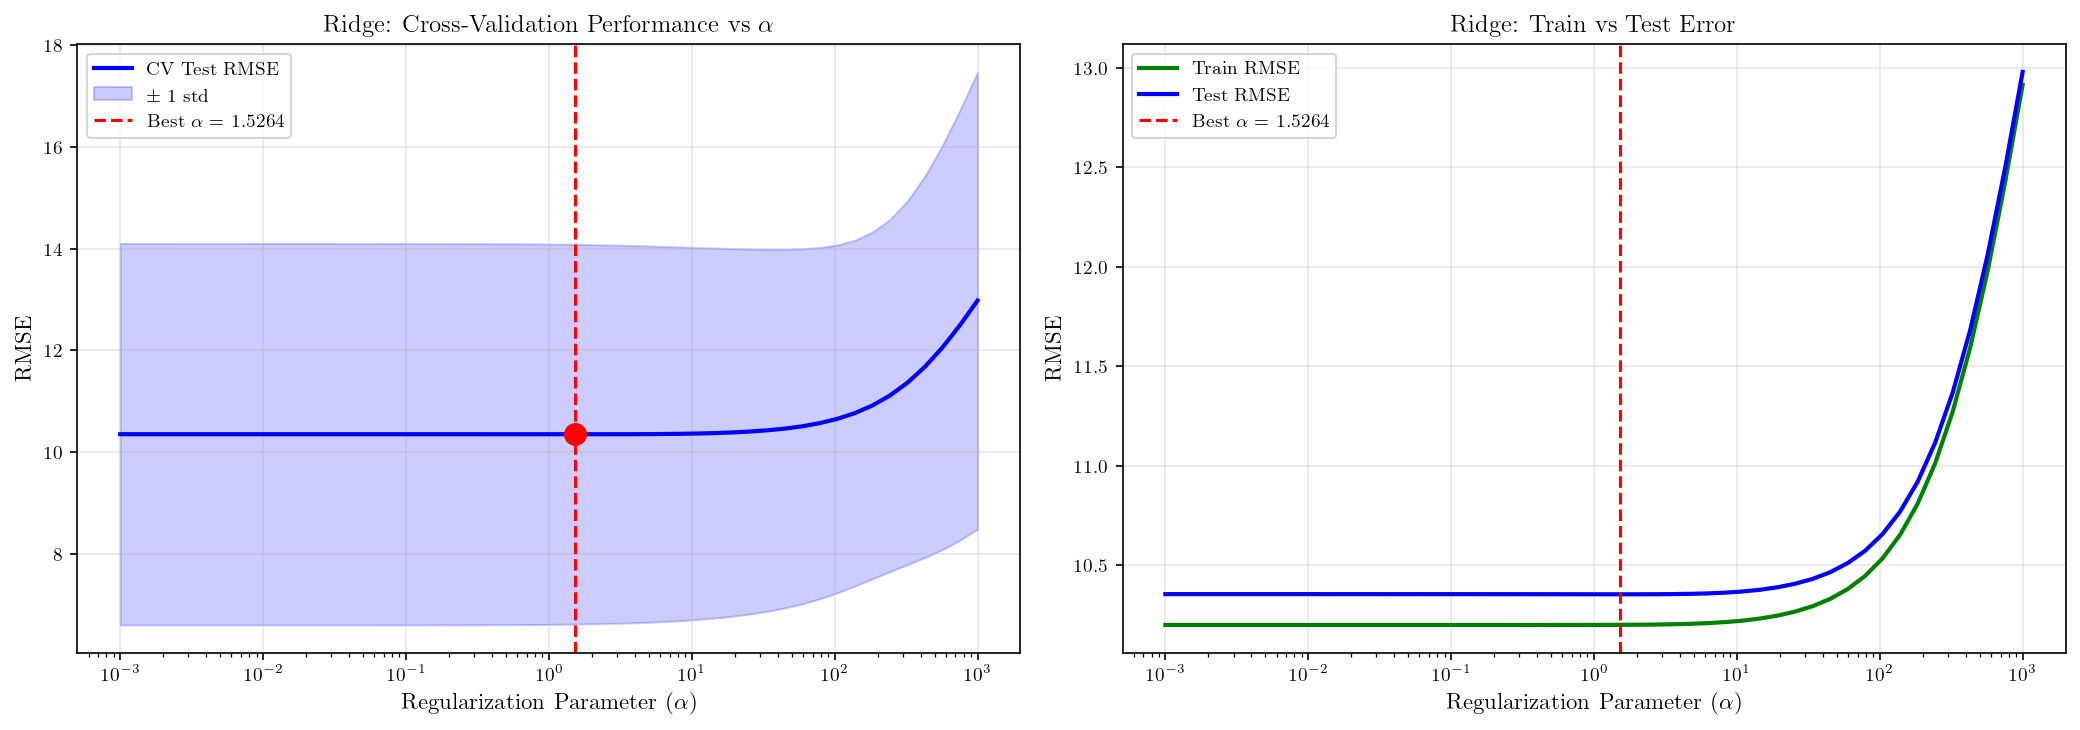

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Test RMSE vs Alpha (log scale)
axes[0].semilogx(alphas_tested, mean_test_rmse, 'b-',
                 linewidth=2, label='CV Test RMSE')
axes[0].fill_between(
    alphas_tested,
    mean_test_rmse - std_test_rmse,
    mean_test_rmse + std_test_rmse,
    alpha=0.2,
    color='blue',
    label='$\pm$ 1 std'
)
axes[0].axvline(best_alpha_ridge, color='red', linestyle='--',
                linewidth=1.5, label=f'Best $\\alpha$ = {best_alpha_ridge:.4f}')
axes[0].scatter([best_alpha_ridge], [best_cv_rmse],
                color='red', s=100, zorder=5)
axes[0].set_xlabel('Regularization Parameter ($\\alpha$)', fontsize=11)
axes[0].set_ylabel('RMSE', fontsize=11)
axes[0].set_title(
    'Ridge: Cross-Validation Performance vs $\\alpha$', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Right plot: Train vs Test RMSE (overfitting analysis)
axes[1].semilogx(alphas_tested, mean_train_rmse, 'g-',
                 linewidth=2, label='Train RMSE')
axes[1].semilogx(alphas_tested, mean_test_rmse, 'b-',
                 linewidth=2, label='Test RMSE')
axes[1].axvline(best_alpha_ridge, color='red', linestyle='--',
                linewidth=1.5, label=f'Best $\\alpha$ = {best_alpha_ridge:.4f}')
axes[1].set_xlabel('Regularization Parameter ($\\alpha$)', fontsize=11)
axes[1].set_ylabel('RMSE', fontsize=11)
axes[1].set_title('Ridge: Train vs Test Error', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("./ridge_hyperparameter_tuning.pdf")
plt.show()

### Train final model

In [67]:
pipe_ridge_final = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=best_alpha_ridge)),
    ]
)

print(f"\nTraining final Ridge model:")
print(f"  Alpha: {best_alpha_ridge:.6f}")
print(f"  Training set: Full train.csv ({len(X_train)} samples)")
print(f"  Features: {X_train.shape[1]}")

pipe_ridge_final.fit(X_train, y_train)
print(f"Model trained successfully!")


Training final Ridge model:
  Alpha: 1.526418
  Training set: Full train.csv (800 samples)
  Features: 8
Model trained successfully!


In [68]:
# Predict on X_test_holdout
y_pred_ridge = pipe_ridge_final.predict(X_test_holdout)

# Calculate metrics
rmse_ridge = np.sqrt(np.mean((y_test_holdout - y_pred_ridge)**2))
rse_ridge = calc_rse(y_test_holdout, y_pred_ridge, p)
r2_ridge = calc_r2(y_test_holdout, y_pred_ridge)

print(f"\nRidge Performance on test.csv ({len(X_test_holdout)} samples):")
print(f"  RMSE: {rmse_ridge:.4f}")
print(f"  RSE:  {rse_ridge:.4f}")
print(f"  R2:   {r2_ridge:.4f}")

# Store results
performance_results["Ridge"] = {
    "RMSE": rmse_ridge,
    "RSE": rse_ridge,
    "R2": r2_ridge,
    "alpha": best_alpha_ridge,
    "CV_RMSE": best_cv_rmse,
}


Ridge Performance on test.csv (100 samples):
  RMSE: 9.5527
  RSE:  10.0139
  R2:   0.5944


### OLS vs Ridge

In [69]:
print(f"\n{'='*70}")
print(f"COMPARISON: OLS vs RIDGE REGRESSION")
print(f"{'='*70}")

print(f"\nOLS (no regularization):")
print(f"  RMSE: {rmse_ols:.4f}")
print(f"  RSE:  {rse_ols:.4f}")
print(f"  R²:   {r2_ols:.4f}")

print(f"\nRidge (α = {best_alpha_ridge:.6f}):")
print(f"  RMSE: {rmse_ridge:.4f}")
print(f"  RSE:  {rse_ridge:.4f}")
print(f"  R²:   {r2_ridge:.4f}")


COMPARISON: OLS vs RIDGE REGRESSION

OLS (no regularization):
  RMSE: 9.5416
  RSE:  10.0023
  R²:   0.5953

Ridge (α = 1.526418):
  RMSE: 9.5527
  RSE:  10.0139
  R²:   0.5944


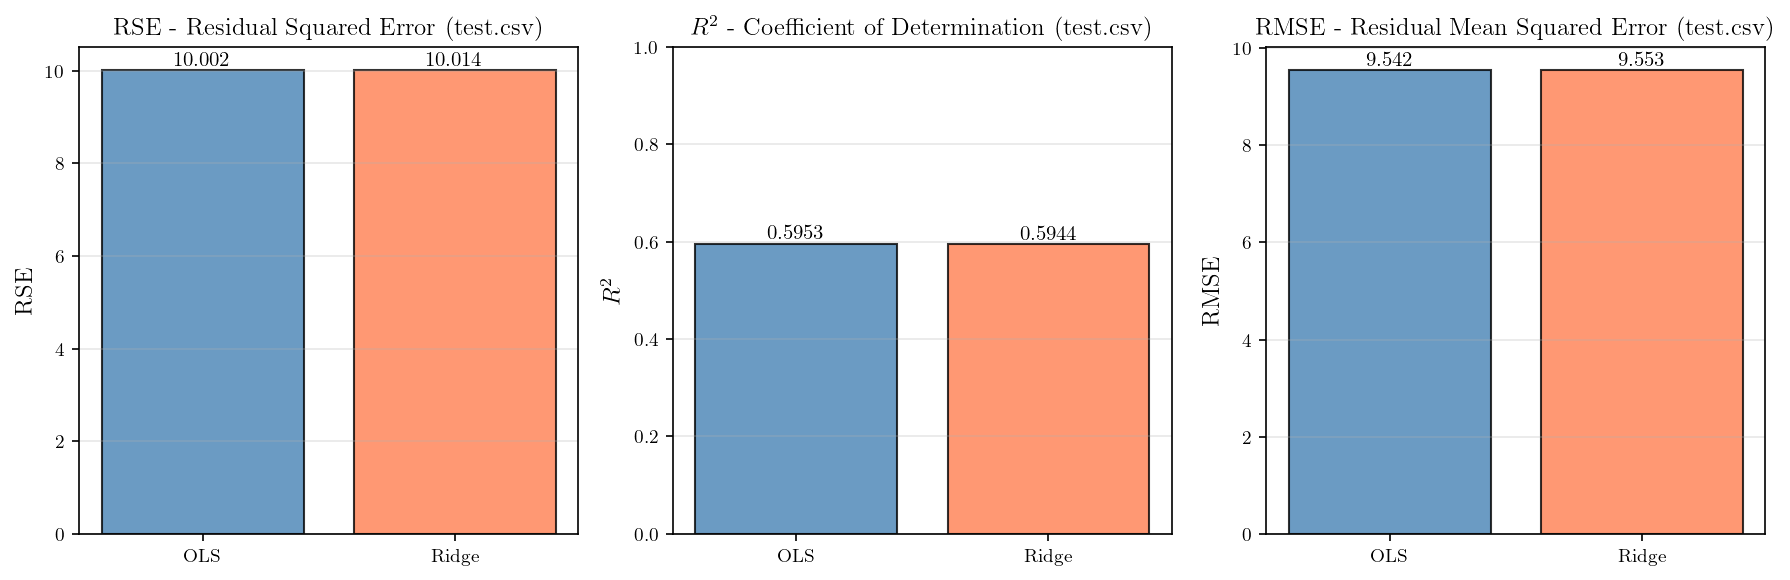

In [112]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

models = ['OLS', 'Ridge']
rse_values = [performance_results['OLS']['RSE'],
              performance_results['Ridge']['RSE']]
r2_values = [performance_results['OLS']['R2'],
             performance_results['Ridge']['R2']]
rmse_values = [performance_results['OLS']['RMSE'],
               performance_results['Ridge']['RMSE']]

# RSE comparison
axes[0].bar(models, rse_values, color=['steelblue',
            'coral'], alpha=0.8, edgecolor='black')
axes[0].set_ylabel('RSE', fontsize=12)
axes[0].set_title('RSE - Residual Squared Error (test.csv)', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, (model, rse) in enumerate(zip(models, rse_values)):
    axes[0].text(i, rse + 0.1, f'{rse:.3f}', ha='center', fontsize=10)

# R² comparison
axes[1].bar(models, r2_values, color=['steelblue', 'coral'],
            alpha=0.8, edgecolor='black')
axes[1].set_ylabel('$R^2$', fontsize=12)
axes[1].set_title(
    r'$R^2$ - Coefficient of Determination (test.csv)', fontsize=12)
axes[1].set_ylim([0, 1.0])
axes[1].grid(axis='y', alpha=0.3)
for i, (model, r2) in enumerate(zip(models, r2_values)):
    axes[1].text(i, r2 + 0.01, f'{r2:.4f}', ha='center', fontsize=10)

# RMSE comparison
axes[2].bar(models, rmse_values, color=['steelblue',
            'coral'], alpha=0.8, edgecolor='black')
axes[2].set_ylabel('RMSE', fontsize=12)
axes[2].set_title('RMSE - Residual Mean Squared Error (test.csv)', fontsize=12)
axes[2].grid(axis='y', alpha=0.3)
for i, (model, rmse) in enumerate(zip(models, rmse_values)):
    axes[2].text(i, rmse + 0.1, f'{rmse:.3f}', ha='center', fontsize=10)


plt.tight_layout()
plt.savefig("./comparison_ols_ridge.pdf")
plt.show()

## Question 3


In [71]:
performance_results

{'OLS': {'RMSE': np.float64(9.541579629003257),
  'RSE': np.float64(10.002293243458862),
  'R2': np.float64(0.5953110867026099),
  'note': 'Trained on train.csv, tested on test.csv'},
 'Ridge': {'RMSE': np.float64(9.552660429401527),
  'RSE': np.float64(10.013909078495109),
  'R2': np.float64(0.5943705965363871),
  'alpha': np.float64(1.5264179671752334),
  'CV_RMSE': np.float64(10.353432857020492)}}

### Grid Search with Cross-Validation

In [72]:
# Define Lasso pipeline
pipe_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso())
])

# Define alpha grid (logarithmic spacing for better coverage)
alphas_lasso = np.logspace(-3, 3, 50)  # 0.001 to 1000
param_grid_lasso = {"lasso__alpha": alphas_lasso}

print(f"\nGrid Search Configuration:")
print(f"  Alpha range: [{alphas_lasso[0]:.4f}, {alphas_lasso[-1]:.2f}]")
print(f"  Number of alpha values: {len(alphas_lasso)}")
print(f"  Cross-validation: 10-fold")
print(f"  Training data: Full train.csv ({len(X_train)} samples)")

# Perform grid search with 10-fold CV on FULL train.csv
cv = KFold(n_splits=10, shuffle=True, random_state=42)
grid_search_lasso = GridSearchCV(
    pipe_lasso,
    param_grid_lasso,
    cv=cv,
    scoring="neg_mean_squared_error",
    return_train_score=True,
    n_jobs=-1,
    verbose=1,
)

print(f"\nRunning Grid Search...")
grid_search_lasso.fit(X_train, y_train)

# Extract results
best_alpha_lasso = grid_search_lasso.best_params_["lasso__alpha"]
best_cv_rmse_lasso = np.sqrt(-grid_search_lasso.best_score_)
cv_results_lasso = grid_search_lasso.cv_results_

print(f"\n{'='*70}")
print(f"BEST HYPERPARAMETER FOUND:")
print(f"{'='*70}")
print(f"  Alpha: {best_alpha_lasso:.6f}")
print(f"  CV RMSE: {best_cv_rmse_lasso:.4f}")


Grid Search Configuration:
  Alpha range: [0.0010, 1000.00]
  Number of alpha values: 50
  Cross-validation: 10-fold
  Training data: Full train.csv (800 samples)

Running Grid Search...
Fitting 10 folds for each of 50 candidates, totalling 500 fits

BEST HYPERPARAMETER FOUND:
  Alpha: 0.068665
  CV RMSE: 10.3470


In [73]:
# Extract training and validation scores
alphas_tested_lasso = cv_results_lasso['param_lasso__alpha'].data
mean_train_rmse_lasso = np.sqrt(-cv_results_lasso['mean_train_score'])
mean_test_rmse_lasso = np.sqrt(-cv_results_lasso['mean_test_score'])
std_test_rmse_lasso = np.sqrt(cv_results_lasso['std_test_score'])

# Find min/max performance
idx_best_lasso = np.argmin(mean_test_rmse_lasso)
idx_worst_lasso = np.argmax(mean_test_rmse_lasso)

print(f"\nPerformance Range:")
print(
    f"  Best  (alpha={alphas_tested_lasso[idx_best_lasso]:.4f}): RMSE = {mean_test_rmse_lasso[idx_best_lasso]:.4f}")
print(
    f"  Worst (alpha={alphas_tested_lasso[idx_worst_lasso]:.4f}): RMSE = {mean_test_rmse_lasso[idx_worst_lasso]:.4f}")
print(
    f"  Performance degradation: {((mean_test_rmse_lasso[idx_worst_lasso]/mean_test_rmse_lasso[idx_best_lasso] - 1)*100):.2f}%")


Performance Range:
  Best  (alpha=0.0687): RMSE = 10.3470
  Worst (alpha=10.9854): RMSE = 16.9198
  Performance degradation: 63.52%


<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/var/folders/tl/52w5zxkd1zl65mr95qllj_3h0000gn/T/ipykernel_21161/4041454874.py:12: SyntaxWarning: invalid escape sequence '\p'
  label='$\pm$ 1 std'


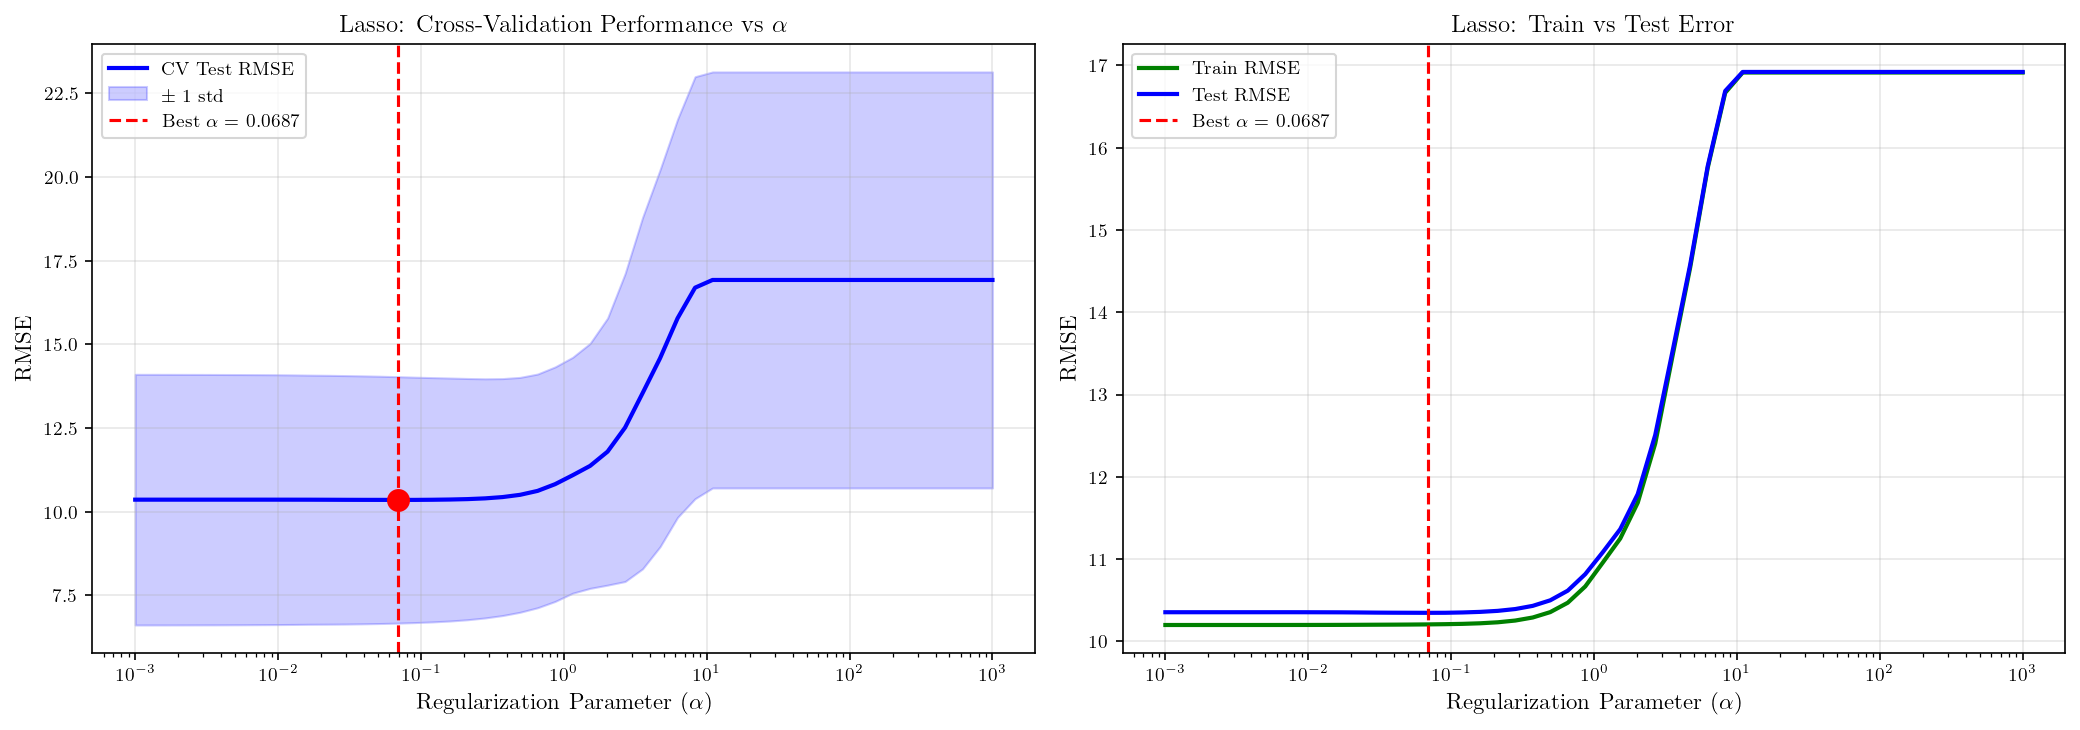

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Test RMSE vs Alpha (log scale)
axes[0].semilogx(alphas_tested_lasso, mean_test_rmse_lasso,
                 'b-', linewidth=2, label='CV Test RMSE')
axes[0].fill_between(
    alphas_tested_lasso,
    mean_test_rmse_lasso - std_test_rmse_lasso,
    mean_test_rmse_lasso + std_test_rmse_lasso,
    alpha=0.2,
    color='blue',
    label='$\pm$ 1 std'
)
axes[0].axvline(best_alpha_lasso, color='red', linestyle='--', linewidth=1.5,
                label=f'Best $\\alpha$ = {best_alpha_lasso:.4f}')
axes[0].scatter([best_alpha_lasso], [best_cv_rmse_lasso],
                color='red', s=100, zorder=5)
axes[0].set_xlabel('Regularization Parameter ($\\alpha$)', fontsize=11)
axes[0].set_ylabel('RMSE', fontsize=11)
axes[0].set_title(
    'Lasso: Cross-Validation Performance vs $\\alpha$', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

# Right plot: Train vs Test RMSE (overfitting analysis)
axes[1].semilogx(alphas_tested_lasso, mean_train_rmse_lasso,
                 'g-', linewidth=2, label='Train RMSE')
axes[1].semilogx(alphas_tested_lasso, mean_test_rmse_lasso,
                 'b-', linewidth=2, label='Test RMSE')
axes[1].axvline(best_alpha_lasso, color='red', linestyle='--', linewidth=1.5,
                label=f'Best $\\alpha$ = {best_alpha_lasso:.4f}')
axes[1].set_xlabel('Regularization Parameter ($\\alpha$)', fontsize=11)
axes[1].set_ylabel('RMSE', fontsize=11)
axes[1].set_title('Lasso: Train vs Test Error', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("./lasso_hyperparameter_tuning.pdf")
plt.show()

In [75]:
pipe_lasso_final = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=best_alpha_lasso, max_iter=10000))
])

print(f"\nTraining final Lasso model:")
print(f"  Alpha: {best_alpha_lasso:.6f}")
print(f"  Training set: Full train.csv ({len(X_train)} samples)")
print(f"  Features: {X_train.shape[1]}")

pipe_lasso_final.fit(X_train, y_train)
print(f"Model trained successfully!")


Training final Lasso model:
  Alpha: 0.068665
  Training set: Full train.csv (800 samples)
  Features: 8
Model trained successfully!


In [76]:
# Predict on X_test_holdout
y_pred_lasso = pipe_lasso_final.predict(X_test_holdout)

# Calculate metrics
rmse_lasso = np.sqrt(np.mean((y_test_holdout - y_pred_lasso)**2))
rse_lasso = calc_rse(y_test_holdout, y_pred_lasso, p)
r2_lasso = calc_r2(y_test_holdout, y_pred_lasso)

print(f"\nLasso Performance on test.csv ({len(X_test_holdout)} samples):")
print(f"  RMSE: {rmse_lasso:.4f}")
print(f"  RSE:  {rse_lasso:.4f}")
print(f"  R²:   {r2_lasso:.4f}")

# Store results
performance_results["Lasso"] = {
    "RMSE": rmse_lasso,
    "RSE": rse_lasso,
    "R2": r2_lasso,
    "alpha": best_alpha_lasso,
    "CV_RMSE": best_cv_rmse_lasso,
    "note": f"Tuned via 10-fold CV, trained on train.csv, tested on test.csv"
}


Lasso Performance on test.csv (100 samples):
  RMSE: 9.5898
  RSE:  10.0528
  R²:   0.5912


### OLS vs Ridge vs Lasso

In [77]:
print(f"\n{'='*70}")
print(f"COMPARISON: OLS vs RIDGE vs LASSO REGRESSION")
print(f"{'='*70}")

print(f"\nOLS (no regularization):")
print(f"  RMSE: {rmse_ols:.4f}")
print(f"  RSE:  {rse_ols:.4f}")
print(f"  R²:   {r2_ols:.4f}")

print(f"\nRidge (α = {best_alpha_ridge:.6f}):")
print(f"  RMSE: {rmse_ridge:.4f}")
print(f"  RSE:  {rse_ridge:.4f}")
print(f"  R²:   {r2_ridge:.4f}")

print(f"\nLasso (α = {best_alpha_lasso:.6f}):")
print(f"  RMSE: {rmse_lasso:.4f}")
print(f"  RSE:  {rse_lasso:.4f}")
print(f"  R²:   {r2_lasso:.4f}")


COMPARISON: OLS vs RIDGE vs LASSO REGRESSION

OLS (no regularization):
  RMSE: 9.5416
  RSE:  10.0023
  R²:   0.5953

Ridge (α = 1.526418):
  RMSE: 9.5527
  RSE:  10.0139
  R²:   0.5944

Lasso (α = 0.068665):
  RMSE: 9.5898
  RSE:  10.0528
  R²:   0.5912


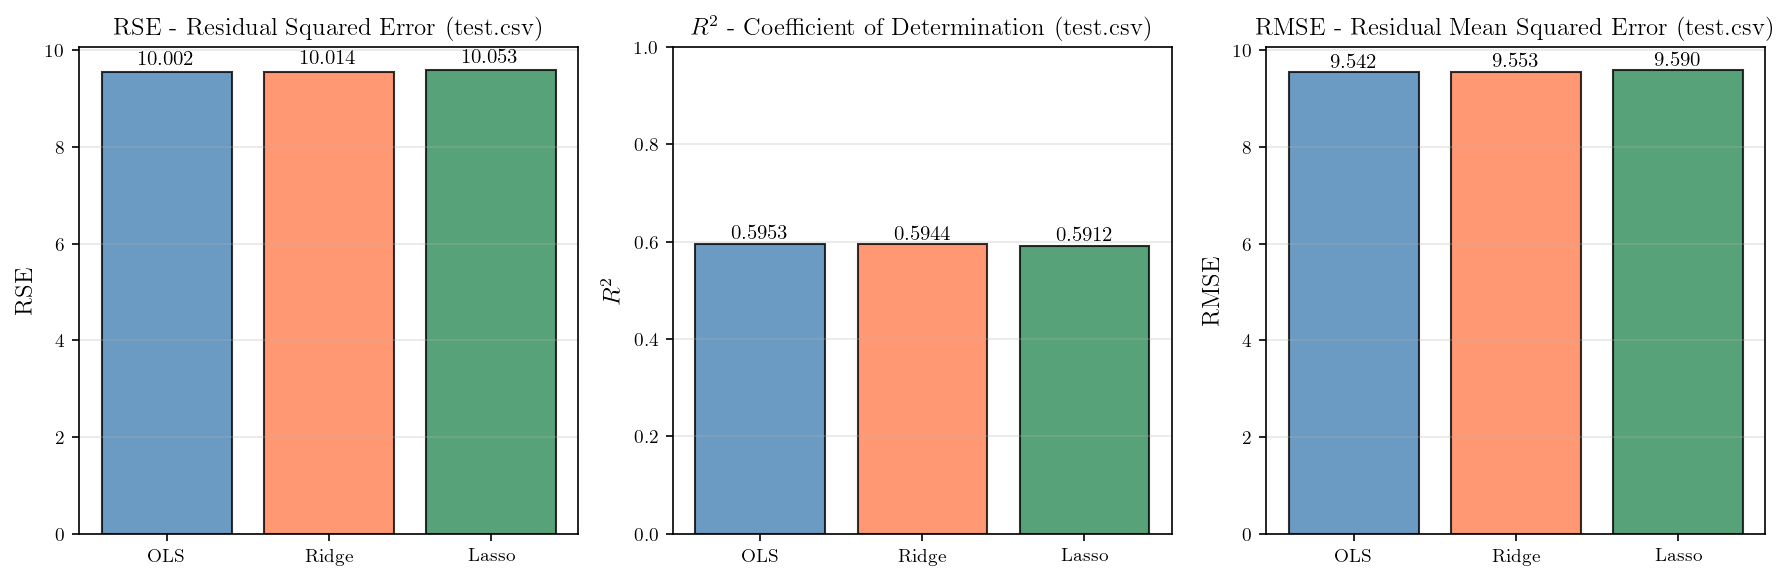

In [102]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

models = ['OLS', 'Ridge', 'Lasso']
rse_values = [performance_results['OLS']['RSE'],
              performance_results['Ridge']['RSE'],
              performance_results['Lasso']['RSE']]
r2_values = [performance_results['OLS']['R2'],
             performance_results['Ridge']['R2'],
             performance_results['Lasso']['R2']]
rmse_values = [performance_results['OLS']['RMSE'],
               performance_results['Ridge']['RMSE'],
               performance_results['Lasso']['RMSE']]

# RSE comparison
axes[0].bar(models, rmse_values, color=['steelblue',
            'coral', 'seagreen'], alpha=0.8, edgecolor='black')
axes[0].set_ylabel('RSE', fontsize=12)
axes[0].set_title('RSE - Residual Squared Error (test.csv)', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, (model, rse) in enumerate(zip(models, rse_values)):
    axes[0].text(i, rse - 0.3, f'{rse:.3f}', ha='center', fontsize=10)

# R2 comparison
axes[1].bar(models, r2_values, color=['steelblue', 'coral', 'seagreen'],
            alpha=0.8, edgecolor='black')
axes[1].set_ylabel('$R^2$', fontsize=12)
axes[1].set_title(
    r'$R^2$ - Coefficient of Determination (test.csv)', fontsize=12)
axes[1].set_ylim([0, 1.0])
axes[1].grid(axis='y', alpha=0.3)
for i, (model, r2) in enumerate(zip(models, r2_values)):
    axes[1].text(i, r2 + 0.01, f'{r2:.4f}', ha='center', fontsize=10)

# RMSE comparison
axes[2].bar(models, rmse_values, color=['steelblue',
            'coral', 'seagreen'], alpha=0.8, edgecolor='black')
axes[2].set_ylabel('RMSE', fontsize=12)
axes[2].set_title('RMSE - Residual Mean Squared Error (test.csv)', fontsize=12)
axes[2].grid(axis='y', alpha=0.3)
for i, (model, rmse) in enumerate(zip(models, rmse_values)):
    axes[2].text(i, rmse + 0.1, f'{rmse:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("./comparison_ols_ridge_lasso.pdf")
plt.show()